# exp107_04 — Evaluación de la mezcla GP funcional (trazas de MATLAB)

Lee el contrato del `exp107_01` y las trazas de `mezcla_gp_iteracion.m`, y compara contra cuatro referencias
**sobre la misma realización y el mismo objetivo** (`curva_suavizada` de la 107):

| Modelo | Origen | Bloque B |
|---|---|---|
| `mezcla_gp` | este experimento | predictiva muestral |
| `psbpm_fd_M4` | `banda_funcional_psbp.npz` del `107_04` | banda nativa |
| `far` | `FARp(p = N_LAGS)` sobre los coeficientes blanqueados, `kn` por `far.cv` (como el `107_05`) | banda gaussiana del modelo |
| `lineal_mco` | MCO con el **mismo** diseño de la mezcla | banda gaussiana |
| `oraculo` | media condicional verdadera del generador | — |

## §1 Imports, contrato y trazas

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score

from model_psbp_fd.utils.rutas import experiment_id, construir_paths
from model_psbp_fd.pipelines import cargar_escenario, cargar_config_evaluacion
from model_psbp_fd.fit.rolling import ventana_movil_funcional
from model_psbp_fd.fit.diagnostics_mcmc import diagnostico_variable
from model_psbp_fd.fit.far_operador import FARp, seleccionar_kn
from model_psbp_fd.fit.intervalos import residuos_para_banda, banda_predictiva_modelo
import mezcla_gp_funcional as mgp

In [2]:
# -- Identificadores: DEBEN coincidir en exp107_01, mezcla_gp_iteracion.m y exp107_04
BASENAME_107 = "escenario_107"      # corrida fuente: sus datos, su particion, su objetivo
BASENAME     = "experimento_107"    # este experimento: sus propios artefactos
ESCENARIO_ID = 1                    # C-1
REPLICA_ID   = 1
M_COV        = 4                    # punto del barrido de la 107 cuyos scores son covariables

EID_107       = experiment_id(BASENAME_107, ESCENARIO_ID, REPLICA_ID, M_COV)
EXPERIMENT_ID = experiment_id(BASENAME, ESCENARIO_ID, REPLICA_ID, M_COV)

KN_MAX = 12          # tope de kn del FAR, como el 107_05

P107  = construir_paths(EID_107, crear=False)
PATHS = construir_paths(EXPERIMENT_ID)

CON    = mgp.cargar_contrato(PATHS)
HP     = CON["hp"]
TRAZAS = mgp.cargar_trazas(PATHS, CON)
EVAL   = cargar_config_evaluacion(PATHS)
ESC    = cargar_escenario(str(P107["raw"] / f"escenario_{ESCENARIO_ID}.npz"))

tau    = ESC["grilla"]
Y, X   = CON["Y"], CON["X"]
t_idx  = CON["t_idx"]
Phi_o, mu = CON["Phi_o"], CON["mu"]
T0     = int(EVAL["T0"])
N_LAGS = int(EVAL["n_lags"])
TR     = t_idx < T0
T0_EV  = int(TR.sum())
NIVEL  = float(EVAL["nivel_credibilidad"])
burn   = HP["mcmc_config"]["burn"]

X_OBJ  = mu + Y @ Phi_o.T            # curva suavizada de la 107 en los origenes evaluados
print(f"{len(TRAZAS)} cadenas · {TRAZAS[0]['A'].shape[0]} extracciones guardadas c/u · "
      f"n = {len(t_idx)} origenes (train {T0_EV})")

2 cadenas · 500 extracciones guardadas c/u · n = 998 origenes (train 698)


## §2 Convergencia (cantidades invariantes a la etiqueta)

In [3]:
pd.DataFrame([{"cadena": t["cadena"], "seed": t["seed"], "ms_por_iter": t["ms_por_iter"],
               **dict(zip(["ms_S", "ms_atomos", "ms_Zstar", "ms_gating", "ms_etiquetas"], np.round(t["ms_por_paso"], 2))),
               "acept_a": t["acept_mov"][0], "acept_b": t["acept_mov"][1], "acept_b_ocup": t["acept_mov"][-1], "mu_a": t["mu_a"].mean()}
              for t in TRAZAS]).round(3)

,cadena,seed,ms_por_iter,ms_S,ms_atomos,ms_Zstar,ms_gating,ms_etiquetas,acept_a,acept_b,acept_b_ocup,mu_a
0,1,51205,27.110,5.10,2.07,5.04,0.82,14.02,0.0,0.879,0.009,1.867
1,2,61178,27.042,5.11,2.07,4.93,0.83,14.06,0.0,0.872,0.001,1.710


,n_cadenas,n_post,ess_min,ess_mean,geweke_max,rhat,converge
cantidad,,,,,,,
loglik,2,2000,5.893,363.495,10.780,1.152,False
E[c1|x] t=701,2,500,334.559,417.279,2.279,1.002,False
E[c2|x] t=701,2,500,372.784,436.392,1.076,0.999,True
E[c1|x] t=775,2,500,29.149,171.524,2.634,1.004,False
E[c2|x] t=775,2,500,40.995,190.134,1.964,1.001,False
E[c1|x] t=850,2,500,399.049,408.224,1.432,1.004,True
E[c2|x] t=850,2,500,208.807,334.276,1.944,0.999,True
E[c1|x] t=925,2,500,392.363,446.181,0.442,1.001,True
E[c2|x] t=925,2,500,339.893,419.946,1.245,1.005,True


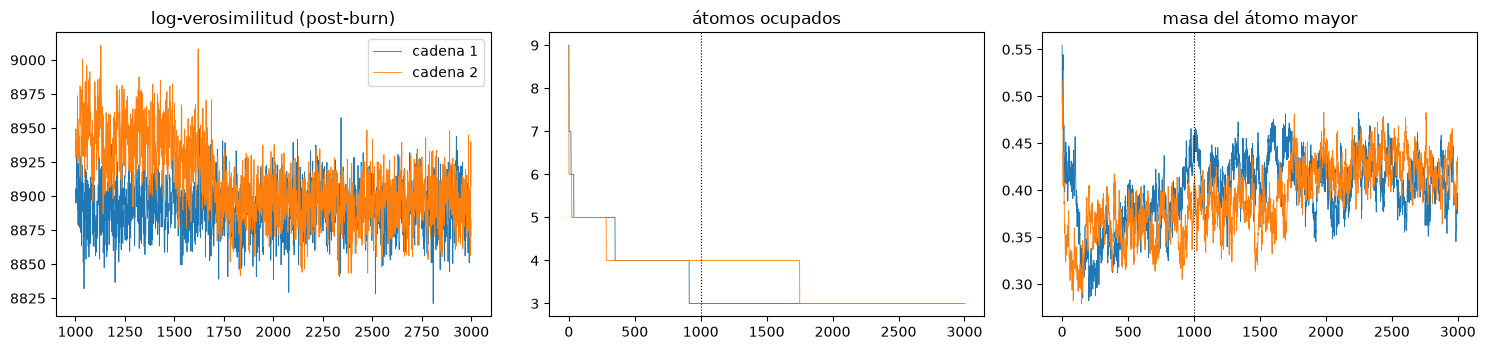

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
for t in TRAZAS:
    ax[0].plot(np.arange(burn, t["loglik"].size), t["loglik"][burn:], lw=.6, label=f"cadena {t['cadena']}")
    ax[1].plot(t["n_ocupados"], lw=.6)
    ax[2].plot(t["masa_max"], lw=.6)
ax[0].set_title("log-verosimilitud (post-burn)"); ax[0].legend()
ax[1].set_title("átomos ocupados"); ax[2].set_title("masa del átomo mayor")
for a in ax[1:]:
    a.axvline(burn, color="k", ls=":", lw=.8)
fig.tight_layout(); fig.savefig(PATHS["out_report"] / "x01_convergencia_trazas.png", dpi=120)

MC = [mgp.media_condicional(t, X) for t in TRAZAS]            # (S, n, K) por cadena
te_rows = np.where(~TR)[0]
ctrl = te_rows[np.linspace(0, te_rows.size - 1, 5).astype(int)]
filas = [{"cantidad": "loglik", **diagnostico_variable(np.stack([t["loglik"][burn:] for t in TRAZAS]))}]
for i in ctrl:
    for k in (0, 1):
        filas.append({"cantidad": f"E[c{k + 1}|x] t={t_idx[i] + 1}",
                      **diagnostico_variable(np.stack([m[:, i, k] for m in MC]))})
pd.DataFrame(filas).set_index("cantidad").round(3)

### §2.1 ¿Encontró los regímenes?

Compara la asignación posterior $S_t$ de las curvas de train con el mecanismo verdadero $Z_t$ del generador
mediante el ARI, que es invariante a la etiqueta. ARI = 0 es azar y ARI = 1 es una recuperación perfecta.

cadena 1: ARI mediana 0.532   [p05 0.439, p95 0.612]
cadena 2: ARI mediana 0.526   [p05 0.412, p95 0.610]


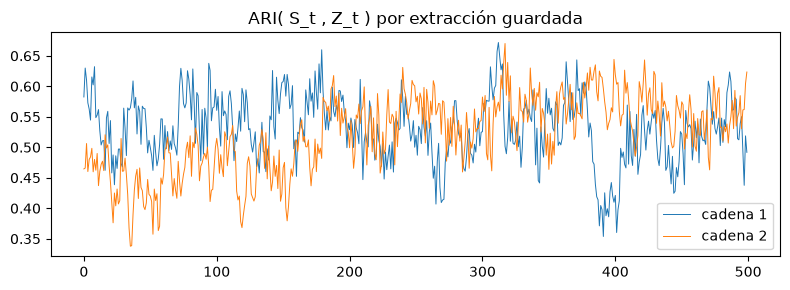

In [5]:
Z_true = ESC["interno_mecanismo"][0][t_idx[TR]]
ARI = {t["cadena"]: np.array([adjusted_rand_score(Z_true, s) for s in t["S"]]) for t in TRAZAS}
for c, a in ARI.items():
    print(f"cadena {c}: ARI mediana {np.median(a):.3f}   [p05 {np.quantile(a, .05):.3f}, p95 {np.quantile(a, .95):.3f}]")
fig, ax = plt.subplots(figsize=(8, 3))
for c, a in ARI.items():
    ax.plot(a, lw=.7, label=f"cadena {c}")
ax.set_title("ARI( S_t , Z_t ) por extracción guardada"); ax.legend()
fig.tight_layout(); fig.savefig(PATHS["out_report"] / "x02_ari_regimenes.png", dpi=120)

## §3 Predicción a $h=1$

In [6]:
# -- mezcla GP --------------------------------------------------------------------
c_hat = np.concatenate(MC).mean(axis=0)
X_mix = mu + c_hat @ Phi_o.T
MUESTRAS = np.concatenate([mgp.muestras_predictivas(t, X, np.random.default_rng(HP["seed_base"] + 17 * t["cadena"]))
                           for t in TRAZAS])
li_mix, ls_mix = mgp.banda_funcional(MUESTRAS, Phi_o, mu, NIVEL)

# -- PSBPM-FD de la 107, M = 4 (banda nativa del 107_04) --------------------------
z = np.load(P107["predict"] / "banda_funcional_psbp.npz", allow_pickle=False)
assert np.array_equal(z["t_orig"] - 1, t_idx), "los origenes del 107_04 no coinciden con los del experimento"
assert str(np.ravel(z["objetivo"])[0]) == "curva_suavizada"
X_psbp, li_psbp, ls_psbp = z["X_pred"], z["li"], z["ls"]

# -- FAR(p) sobre los coeficientes blanqueados, kn por far.cv (como el 107_05) -----
# FARp.predict_serie necesita la serie COMPLETA t = 0..T-1 (el contrato solo
# guarda los origenes t >= N_LAGS): se rearma desde la representacion de la 107
# y se verifica que coincida con la respuesta del contrato.
from model_psbp_fd.pipelines import cargar_representacion, cargar_fpca
fr, THETA, _ = cargar_representacion(P107)
L_GRAM = np.linalg.cholesky(cargar_fpca(P107).W)
THETA_W = (THETA - THETA[:T0].mean(axis=0)) @ L_GRAM              # = coeficientes c_t, t = 0..T-1
assert np.allclose(THETA_W[t_idx], Y), "los coeficientes del contrato no son los de la 107"
cv = seleccionar_kn(THETA_W[:T0], kn_max=min(KN_MAX, THETA_W.shape[1]), pesos="conteo", p=N_LAGS)
FAR_MOD = FARp(p=N_LAGS, kn=cv.kn_L2, pesos="conteo").fit(THETA_W[:T0])
c_far = FAR_MOD.predict_serie(THETA_W)
assert c_far.shape == Y.shape
X_far = mu + c_far @ Phi_o.T
li_far, ls_far = banda_predictiva_modelo(X_far, residuos_para_banda(X_OBJ, X_far, TR), nivel=NIVEL)

# -- lineal MCO, mismo diseno que la mezcla --------------------------------------------
B_ols, *_ = np.linalg.lstsq(X[TR], Y[TR], rcond=None)
X_lin = mu + (X @ B_ols) @ Phi_o.T
li_lin, ls_lin = banda_predictiva_modelo(X_lin, residuos_para_banda(X_OBJ, X_lin, TR), nivel=NIVEL)

# -- oraculo: media condicional verdadera del generador, en la curva ----------------
X_or = ESC["interno_media_condicional_curva"][0][t_idx]

MODELOS = {"mezcla_gp": (X_mix, li_mix, ls_mix), "psbpm_fd_M4": (X_psbp, li_psbp, ls_psbp),
           "far": (X_far, li_far, ls_far), "lineal_mco": (X_lin, li_lin, ls_lin),
           "oraculo": (X_or, None, None)}
print(f"FAR: kn = {cv.kn_L2} (L2)   ·   muestras predictivas {MUESTRAS.shape}")

FAR: kn = 5 (L2)   ·   muestras predictivas (1000, 998, 14)


## §4 Bloques A y B sobre la ventana móvil

Las ventanas se leen de `eval_config.json`, que es el de la 107. Las ventanas que cruzan `T0` se excluyen.

In [7]:
VM = EVAL["ventana_movil"]
VENTANAS_W = VM["w"]
W_REF = VENTANAS_W[len(VENTANAS_W) // 2]
METRICAS_A, METRICAS_B = EVAL["metricas_bloque_A"], EVAL["metricas_bloque_B"]

TABLAS = {}
for nombre, (Xp, li, ls) in MODELOS.items():
    for w in VENTANAS_W:
        tb = ventana_movil_funcional(X_OBJ, Xp, tau, T0_EV, w=w, paso=VM["paso"],
                                     solapadas=VM["solapadas"], t_offset=int(t_idx[0]),
                                     li=li, ls=ls, nivel=NIVEL, bloque_A=True)
        tb["modelo"], tb["w"] = nombre, w
        TABLAS[(nombre, w)] = tb
VMT = pd.concat(TABLAS.values(), ignore_index=True)
VMT = VMT[~VMT["cruza_T0"]]

# relaciones que no deben romperse (CLAUDE.md §3.1)
assert (VMT["mae_f"] <= VMT["l2_medio"] + 1e-12).all()
assert (VMT["l2_medio"] <= VMT["linf_medio"] + 1e-12).all()
assert (VMT["linf_medio"] <= VMT["linf_max"] + 1e-12).all()
vb = VMT[VMT["winkler"].notna()]
assert (vb["picp_simultaneo"] <= vb["picp"] + 1e-12).all()
assert (vb["winkler"] <= vb["winkler_max_medio"] + 1e-12).all()
assert (vb["winkler_max_medio"] <= vb["winkler_max_glob"] + 1e-12).all()

cols = METRICAS_A + METRICAS_B
(VMT[VMT.w == W_REF].groupby(["bloque", "modelo"])[cols].mean().round(4))

mae_f  rmse_f  linf_medio  linf_max    mpiw    picp  \
bloque modelo                                                              
test   far          0.7073  0.8864      1.6583    2.9830  3.3194  0.9371   
       lineal_mco   0.7117  0.8948      1.6733    3.0367  3.2731  0.9308   
       mezcla_gp    0.6912  0.8733      1.6407    3.0757  3.2416  0.9354   
       oraculo      0.6702  0.8451      1.5797    2.9904     NaN     NaN   
       psbpm_fd_M4  0.7084  0.8880      1.6632    3.0274  3.3265  0.9351   
train  far          0.6727  0.8485      1.5957    2.7859  3.3194  0.9471   
       lineal_mco   0.6642  0.8365      1.5615    2.7672  3.2731  0.9476   
       mezcla_gp    0.6415  0.8094      1.5111    2.7569  3.2217  0.9536   
       oraculo      0.6562  0.8295      1.5521    2.8532     NaN     NaN   
       psbpm_fd_M4  0.6823  0.8587      1.6155    2.8350  3.3072  0.9408   

                    picp_simultaneo  winkler  winkler_max_medio  \
bloque modelo                                                     
test   far                   0.5476   4.2291            12.0166   
       lineal_mco            0.5150   4.3141            12.8122   
       mezcla_gp             0.5300   4.1767            12.4925   
       oraculo                  NaN      NaN                NaN   
       psbpm_fd_M4           0.5027   4.2645            12.7855   
train  far                   0.5848   3.9922            10.1188   
       lineal_mco            0.5897   3.9219             9.7628   
       mezcla_gp             0.6092   3.7547             9.0121   
       oraculo                  NaN      NaN                NaN   
       psbpm_fd_M4           0.5219   4.0641            11.2415   

                    winkler_max_glob  
bloque modelo                         
test   far                   55.2856  
       lineal_mco            58.3661  
       mezcla_gp             56.5386  
       oraculo                   NaN  
       psbpm_fd_M4           53.7612  
train  far                   47.3071  
       lineal_mco            47.5021  
       mezcla_gp             43.3588  
       oraculo                   NaN  
       psbpm_fd_M4           49.9255

### §4.1 Quién gana cada ventana de test (`w = W_REF`): `mezcla_gp` contra cada referencia

In [8]:
def ganancias(rival, w=W_REF):
    sel = lambda m: VMT[(VMT.w == w) & (VMT.bloque == "test") & (VMT.modelo == m)].set_index("t_centro")
    a, b = sel("mezcla_gp"), sel(rival)
    fila = {"rival": rival}
    for m in METRICAS_A + ["winkler", "winkler_max_medio", "winkler_max_glob"]:
        if b[m].notna().all():
            fila[m] = float((a[m] < b[m]).mean())
    for m in ("picp", "picp_simultaneo"):        # gana quien queda mas cerca del nominal
        if b[m].notna().all():
            fila[m] = float(((a[m] - NIVEL).abs() < (b[m] - NIVEL).abs()).mean())
    return fila
print("fraccion de ventanas de test en que mezcla_gp gana (mpiw no rankea):")
pd.DataFrame([ganancias(r) for r in MODELOS if r != "mezcla_gp"]).set_index("rival").round(3)

fraccion de ventanas de test en que mezcla_gp gana (mpiw no rankea):


,mae_f,rmse_f,linf_medio,linf_max,winkler,winkler_max_medio,winkler_max_glob,picp,picp_simultaneo
rival,,,,,,,,,
psbpm_fd_M4,0.782,0.708,0.712,0.432,0.642,0.568,0.480,0.491,0.531
far,0.845,0.745,0.631,0.310,0.661,0.339,0.450,0.458,0.232
lineal_mco,0.945,0.945,0.900,0.435,0.919,0.694,0.601,0.705,0.487
oraculo,0.085,0.055,0.022,0.406,NaN,NaN,NaN,NaN,NaN


### §4.2 Resumen mín / máx / promedio en test (`w = W_REF`)

In [9]:
RESUMEN = (VMT[(VMT.w == W_REF) & (VMT.bloque == "test")]
           .groupby("modelo")[cols].agg(["min", "max", "mean"]).T.round(4))
RESUMEN.to_csv(PATHS["out_report"] / "x03_resumen_test.csv")
RESUMEN

modelo                      far  lineal_mco  mezcla_gp  oraculo  psbpm_fd_M4
mae_f             min    0.6156      0.6148     0.5888   0.5623       0.6100
                  max    0.7944      0.8025     0.7983   0.8003       0.7819
                  mean   0.7073      0.7117     0.6912   0.6702       0.7084
rmse_f            min    0.7608      0.7630     0.7340   0.6992       0.7535
                  max    1.0115      1.0212     1.0160   1.0015       0.9844
                  mean   0.8864      0.8948     0.8733   0.8451       0.8880
linf_medio        min    1.4507      1.4494     1.4128   1.3783       1.4202
                  max    1.8734      1.8639     1.8602   1.8308       1.8567
                  mean   1.6583      1.6733     1.6407   1.5797       1.6632
linf_max          min    2.2105      2.2253     2.1744   2.0421       2.0650
                  max    3.5756      3.7492     4.1652   4.1932       3.6631
                  mean   2.9830      3.0367     3.0757   2.9904       3.0274
mpiw              min    3.3194      3.2731     3.1623      NaN       3.2320
                  max    3.3194      3.2731     3.3331      NaN       3.4658
                  mean   3.3194      3.2731     3.2416      NaN       3.3265
picp              min    0.8902      0.8822     0.8951      NaN       0.9053
                  max    0.9662      0.9636     0.9622      NaN       0.9658
                  mean   0.9371      0.9308     0.9354      NaN       0.9351
picp_simultaneo   min    0.3000      0.3333     0.3333      NaN       0.3333
                  max    0.7333      0.7333     0.7000      NaN       0.6667
                  mean   0.5476      0.5150     0.5300      NaN       0.5027
winkler           min    3.5691      3.5832     3.5051      NaN       3.6562
                  max    5.2133      5.3421     5.0936      NaN       5.1468
                  mean   4.2291      4.3141     4.1767      NaN       4.2645
winkler_max_medio min    7.3693      7.6114     7.6219      NaN       8.1372
                  max   18.6592     19.1654    18.0315      NaN      17.7924
                  mean  12.0166     12.8122    12.4925      NaN      12.7855
winkler_max_glob  min   23.0808     24.6868    25.7264      NaN      24.5410
                  max   78.0093     85.8067    95.9737      NaN      78.7643
                  mean  55.2856     58.3661    56.5386      NaN      53.7612

## §5 Figuras

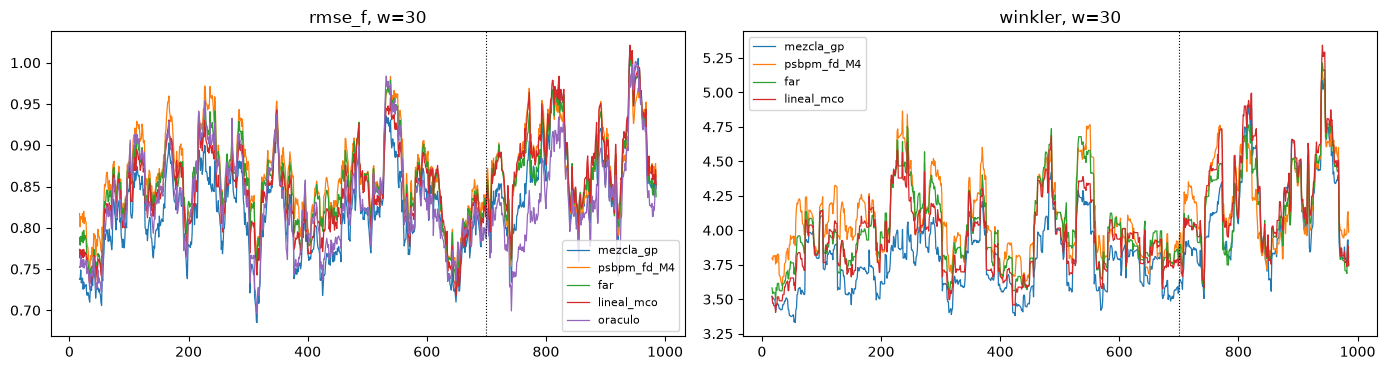

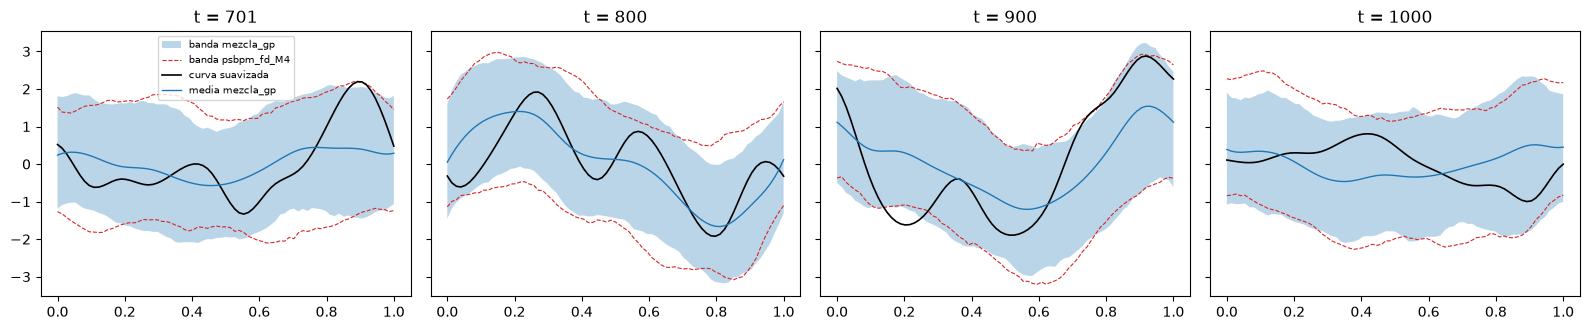

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(14, 3.8))
for nombre in MODELOS:
    tb = TABLAS[(nombre, W_REF)]
    ax[0].plot(tb["t_centro"], tb["rmse_f"], lw=.9, label=nombre)
    if MODELOS[nombre][1] is not None:
        ax[1].plot(tb["t_centro"], tb["winkler"], lw=.9, label=nombre)
for a, tit in zip(ax, ("rmse_f", "winkler")):
    a.axvline(T0, color="k", ls=":", lw=.8); a.set_title(f"{tit}, w={W_REF}"); a.legend(fontsize=8)
fig.tight_layout(); fig.savefig(PATHS["out_report"] / "x04_ventana_movil.png", dpi=120)

ej = te_rows[np.linspace(0, te_rows.size - 1, 4).astype(int)]
fig, ax = plt.subplots(1, 4, figsize=(16, 3.4), sharey=True)
for a, i in zip(ax, ej):
    a.fill_between(tau, li_mix[i], ls_mix[i], alpha=.3, label="banda mezcla_gp")
    a.plot(tau, li_psbp[i], "C3--", lw=.8); a.plot(tau, ls_psbp[i], "C3--", lw=.8, label="banda psbpm_fd_M4")
    a.plot(tau, X_OBJ[i], "k", lw=1.2, label="curva suavizada")
    a.plot(tau, X_mix[i], "C0", lw=1, label="media mezcla_gp")
    a.set_title(f"t = {t_idx[i] + 1}")
ax[0].legend(fontsize=7)
fig.tight_layout(); fig.savefig(PATHS["out_report"] / "x05_curvas_test.png", dpi=120)